# E-commerce Customer Purchase Prediction: End-to-End ML Pipeline

## Overview
In this capstone project, you'll step into the role of a data scientist working for an e-commerce company. Your task is to build a complete machine learning pipeline that predicts whether a customer will make a purchase based on their behavior and demographic information. This represents a real business challenge that can help companies optimize their marketing strategies, personalize customer experiences, and increase conversion rates.

This project integrates key machine learning skills including data preprocessing, exploratory data analysis, feature engineering, model training, evaluation, and hyperparameter tuning
You'll work with realistic e-commerce customer data that includes demographics, browsing behavior, and purchase history
Your final model will provide actionable insights that could directly impact business decisions


## Task 1: Data Loading and Exploration
As the first step in your project, you need to understand the dataset you're working with. You'll load the e-commerce customer data and perform initial exploration to understand the structure, identify patterns, and detect any data quality issues.

**Steps:**
1. Load the dataset `customer_purchase_data.csv` into a pandas DataFrame named `df`.


2. Display:

    - The dataset shape and the first few rows.
    - Information about data types and missing values using df.info().
    - A statistical summary using df.describe().
    - Missing values for each column.      
    
    
3. Explore the target variable `PurchaseStatus`:

    - Display value counts (both absolute and normalized).
    - Plot the distribution using a countplot.    
    

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset 'customer_purchase_data.csv' into a dataframe named 'df'
df = pd.read_csv(r"customer_purchase_data.csv")


In [2]:
# Explore the dataset
print("First Five Rows in the Data\n")
print(df.head())


First Five Rows in the Data

   Age  Gender   AnnualIncome  NumberOfPurchases  ProductCategory  \
0   40       1   66120.267939                  8                0   
1   20       1   23579.773583                  4                2   
2   27       1  127821.306432                 11                2   
3   24       1  137798.623120                 19                3   
4   31       1   99300.964220                 19                1   

   TimeSpentOnWebsite  LoyaltyProgram  DiscountsAvailed  PurchaseStatus  
0           30.568601               0                 5               1  
1           38.240097               0                 5               0  
2           31.633212               1                 0               1  
3           46.167059               0                 4               1  
4           19.823592               0                 0               1  


In [3]:
print("\nInformation on Datatypes and missing val\n")
print(df.info())



Information on Datatypes and missing val

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 1500 non-null   int64  
 1   Gender              1500 non-null   int64  
 2   AnnualIncome        1500 non-null   float64
 3   NumberOfPurchases   1500 non-null   int64  
 4   ProductCategory     1500 non-null   int64  
 5   TimeSpentOnWebsite  1500 non-null   float64
 6   LoyaltyProgram      1500 non-null   int64  
 7   DiscountsAvailed    1500 non-null   int64  
 8   PurchaseStatus      1500 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 105.6 KB
None


In [4]:
print("\nStatistical summary of the dataset\n")
print(df.describe())



Statistical summary of the dataset

               Age       Gender   AnnualIncome  NumberOfPurchases  \
count  1500.000000  1500.000000    1500.000000        1500.000000   
mean     44.298667     0.504667   84249.164338          10.420000   
std      15.537259     0.500145   37629.493078           5.887391   
min      18.000000     0.000000   20001.512518           0.000000   
25%      31.000000     0.000000   53028.979155           5.000000   
50%      45.000000     1.000000   83699.581476          11.000000   
75%      57.000000     1.000000  117167.772858          15.000000   
max      70.000000     1.000000  149785.176481          20.000000   

       ProductCategory  TimeSpentOnWebsite  LoyaltyProgram  DiscountsAvailed  \
count      1500.000000         1500.000000     1500.000000       1500.000000   
mean          2.012667           30.469040        0.326667          2.555333   
std           1.428005           16.984392        0.469151          1.705152   
min           0.00000

In [5]:
print("\nMissing values in each cloumn\n")
print(df.isnull().sum())



Missing values in each cloumn

Age                   0
Gender                0
AnnualIncome          0
NumberOfPurchases     0
ProductCategory       0
TimeSpentOnWebsite    0
LoyaltyProgram        0
DiscountsAvailed      0
PurchaseStatus        0
dtype: int64


## Task 2: Data Preprocessing and Feature Engineering
Now that you understand the dataset, it's time to prepare it for machine learning. You'll handle any data quality issues, encode categorical variables, scale numerical features, and create any additional features that might improve your model.

**Steps:**
1. Handle Missing Values:
 - Check for missing values in all columns.
 - For `numerical_features` (Age, AnnualIncome, NumberOfPurchases, TimeSpentOnWebsite, DiscountsAvailed):
    - Fill missing values using the median of each column.
 - For `categorical_features` (Gender, ProductCategory, LoyaltyProgram):
    - Fill missing values using the mode (most frequent value) of each column.
    
    
2. Create a New Feature:
 - Add a feature called `AvgSpendingPerPurchase` calculated as:
    - AvgSpendingPerPurchase = AnnualIncome / NumberOfPurchases
 - Replace NumberOfPurchases == 0 with 1 in the denominator to avoid division by zero.
 
 
3. Update the Feature Lists:
 - After creating the new feature, append `AvgSpendingPerPurchase` to the list of numerical features.
 

4. Build a Preprocessing Pipeline named `preprocessor`:
 - Use `ColumnTransformer` to preprocess your data:
    - Scale numerical features using StandardScaler.
    - One-hot encode categorical features using OneHotEncoder(drop='first').
    

5. Split the Dataset:
 - Separate the target variable `PurchaseStatus` from the feature matrix. Split the data into features `X` and target `y`
 - Use `train_test_split` with `X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)`
        

6. Fit and Transform:
 - Fit the preprocessor on the training data only.
 - Transform both training and test sets using the fitted preprocessor.
 - Ensure the processed outputs contain no missing values and are in numerical form.
 

In [9]:
from pandas.core import construction
import enum
# Import additional libraries
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# Step 1: Check if missing values exist and handle them

# Define feature types
categorical_features = ['Gender', 'ProductCategory', 'LoyaltyProgram']
numerical_features = ['Age', 'AnnualIncome', 'NumberOfPurchases',
                      'TimeSpentOnWebsite', 'DiscountsAvailed']


# Fill missing values for numerical features with the median of each column
# for col in numerical_features:
#     df[col] = df[col].fillna(df[col].median())


# Fill missing values for categorical features with the mode of each column
# for col in categorical_features:
#     df[col] = df[col].fillna(df[col].mode()[0])

# commenting them as we have no missing values checked above          

In [10]:
# Step 2: Create a new feature AvgSpendingPerPurchase

# Replace 0 with 1 in the denominator to avoid division by zero
denominator = np.where(df['NumberOfPurchases'] == 0, 1, df['NumberOfPurchases'])
df['AvgSpendingPerPurchase'] = df['AnnualIncome'] / denominator
# Check for infinity values to be safe
print("Count of infinity values:", np.isinf(df['AvgSpendingPerPurchase']).sum())

Count of infinity values: 0


In [11]:
# Step 3: Append AvgSpendingPerPurchase to the list of numerical features
numerical_features.append("AvgSpendingPerPurchase")


In [12]:
# Step 4: Create preprocessor with pipelines for categorical and numerical features
preprocessor = ColumnTransformer(
    transformers = [
        ("neumerical",StandardScaler(),numerical_features),
        ("categorical",OneHotEncoder(drop='first'),categorical_features)
    ]
)

In [13]:
# Step 5: Split the Dataset as outlined in the instructional steps above
# Split the data into features and target
X = df.drop("PurchaseStatus",axis=1)
y = df["PurchaseStatus"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Step 6: Fit and Transform

# Fit the preprocessor on the training data only and transform it
X_train_processed = preprocessor.fit_transform(X_train)
# Transform the test set using the fitted preprocessor (do NOT fit again)
X_test_processed = preprocessor.transform(X_test)


In [15]:
# Check if there are any missing values (np.isnan will return True for NaN values)
print("Missing values in X_train_processed:", np.isnan(X_train_processed).sum())
print("Missing values in X_test_processed:", np.isnan(X_test_processed).sum())
# Check the data type and shape to ensure it's numerical and properly formatted
print("\nX_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)
print("Data type:", X_train_processed.dtype)

Missing values in X_train_processed: 0
Missing values in X_test_processed: 0

X_train_processed shape: (1200, 12)
X_test_processed shape: (300, 12)
Data type: float64


## Task 3: Model Training and Baseline Evaluation
In this task, you'll train multiple classification models to predict customer purchase behavior. You'll establish baseline performance metrics to later compare with your optimized models.


**Steps:**
1. Define and train the following models using the processed training data:
    - Logistic Regression
    - Decision Tree Classifier
    - Random Forest Classifier
    

2. Use each model to predict on the test set.


3. Calculate the following metrics for each model:
    - Accuracy
    - Precision
    - Recall
    - F1 Score
    - ROC-AUC Score
    

4. Store each model’s results in a dictionary named `results` with metric names as keys. So the dictionary may look something like:
```
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC-AUC': roc_auc,
        'Model': model,
        'Predictions': y_pred,
        'Probabilities': y_pred_proba
    }
    ```


Training Logistic Regression...
Logistic Regression Results:
Accuracy: 0.8400
Precision: 0.8534
Recall: 0.7615
F1 Score: 0.8049
ROC-AUC: 0.8308

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86       170
           1       0.85      0.76      0.80       130

    accuracy                           0.84       300
   macro avg       0.84      0.83      0.83       300
weighted avg       0.84      0.84      0.84       300



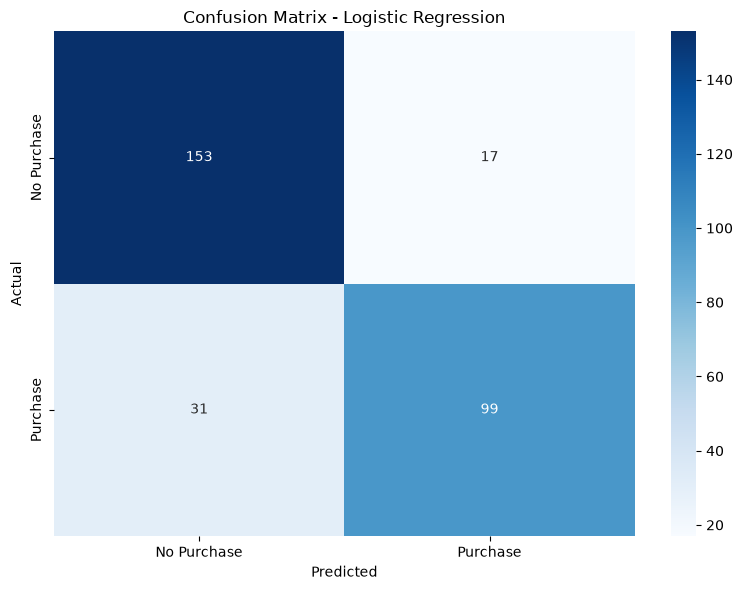


Training Decision Tree...
Decision Tree Results:
Accuracy: 0.8533
Precision: 0.8359
Recall: 0.8231
F1 Score: 0.8295
ROC-AUC: 0.8498

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.88      0.87       170
           1       0.84      0.82      0.83       130

    accuracy                           0.85       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.85      0.85      0.85       300



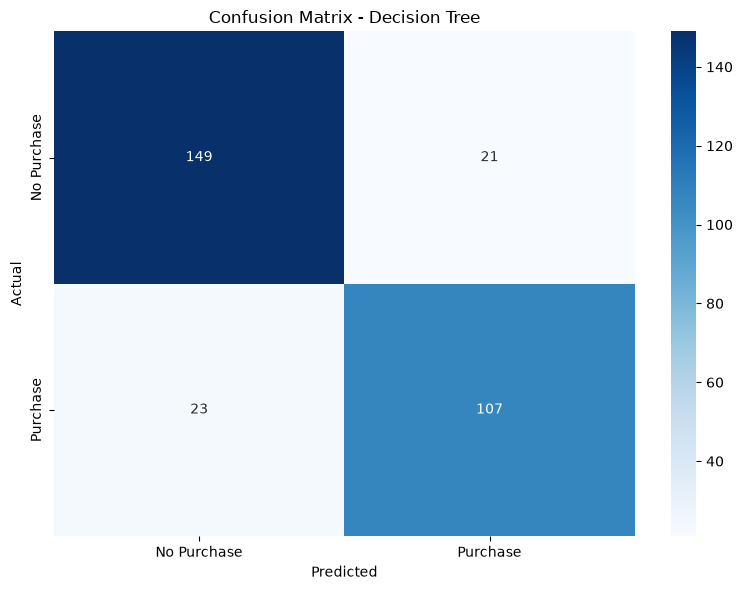


Training Random Forest...
Random Forest Results:
Accuracy: 0.9333
Precision: 0.9435
Recall: 0.9000
F1 Score: 0.9213
ROC-AUC: 0.9294

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.94       170
           1       0.94      0.90      0.92       130

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300



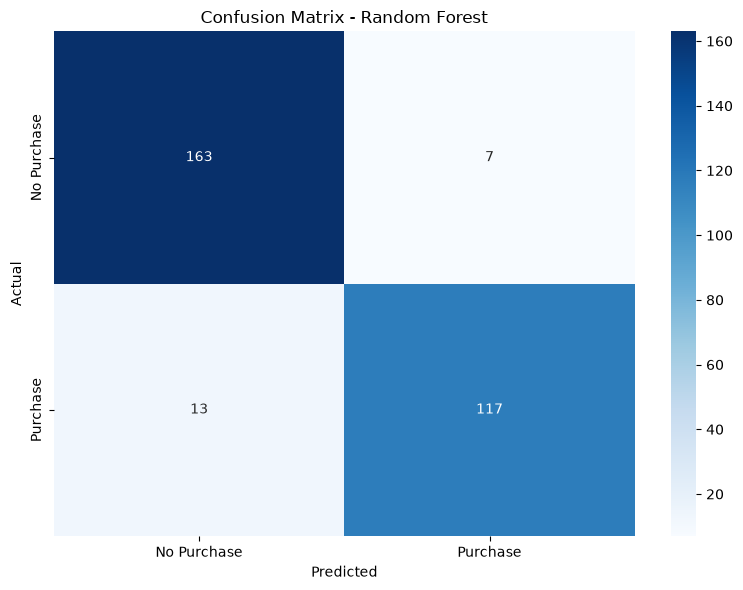

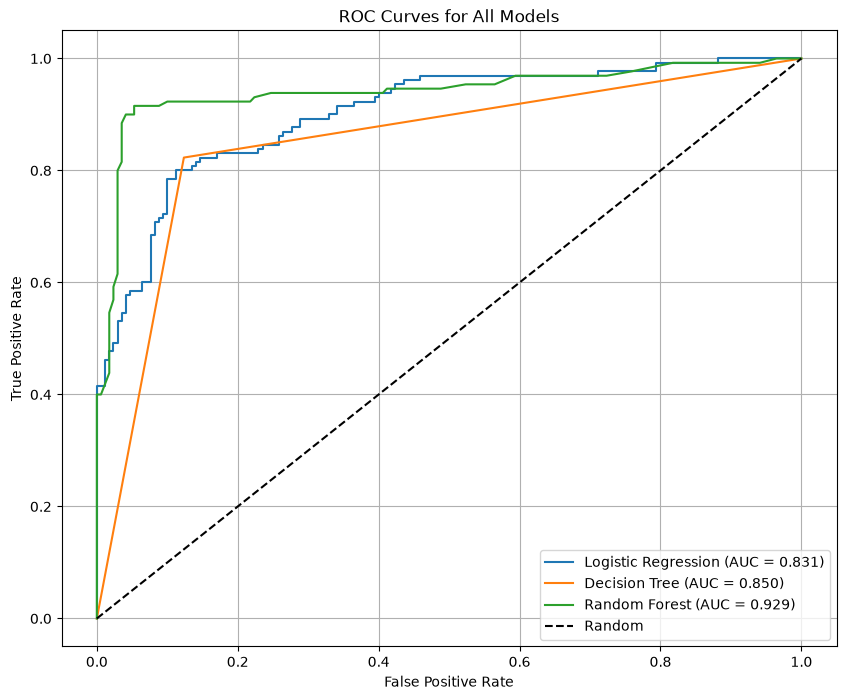


Model Comparison:
           Logistic Regression  Decision Tree  Random Forest
Accuracy              0.840000       0.853333       0.933333
Precision             0.853448       0.835938       0.943548
Recall                0.761538       0.823077       0.900000
F1 Score              0.804878       0.829457       0.921260
ROC-AUC               0.830769       0.849774       0.929412


<Figure size 1200x800 with 0 Axes>

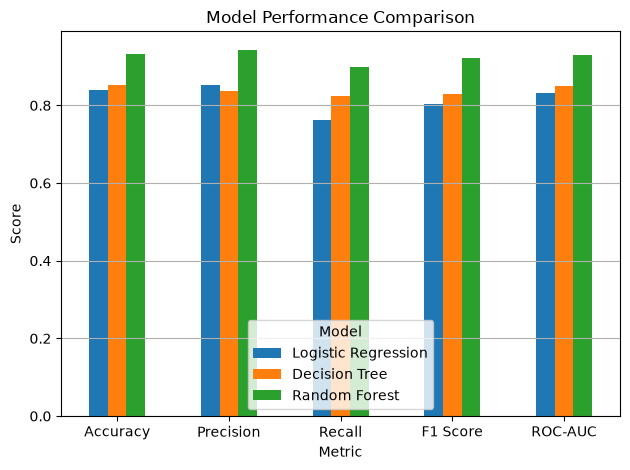

In [27]:
# Import modeling libraries
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

# Create a dictionary to store models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Dictionary to store results
results = {}

# Train and evaluate each model
for name, model in models.items():
    print(f"\nTraining {name}...")    
      
    # Step 1: Train the model
    model.fit(X_train_processed,y_train)
    
    
    # Step 2: Make predictions
    y_pred = model.predict(X_test_processed)
    y_pred_proba = model.predict_proba(X_test_processed)[:,1]
        
    # Step 3: Calculate metrics
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    roc_auc = roc_auc_score(y_test,y_pred)
       
    
    # Step 4: Store results
    # complete the code
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC-AUC': roc_auc,
        'Model': model,
        'Predictions': y_pred,
        'Probabilities': y_pred_proba
    }
     # Print results
    print(f"{name} Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

    # Print classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Create confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Purchase', 'Purchase'],
                yticklabels=['No Purchase', 'Purchase'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

# Plot ROC curves for all models
plt.figure(figsize=(10, 8))
for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result['Probabilities'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {result['ROC-AUC']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models')
plt.legend()
plt.grid(True)
plt.show()

# Create a dataframe to compare model performances
comparison_df = pd.DataFrame({
    model_name: {
        metric: results[model_name][metric]
        for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
    }
    for model_name in results.keys()
})

print("\nModel Comparison:")
print(comparison_df)

# Visualize model comparison
plt.figure(figsize=(12, 8))
comparison_df.plot(kind='bar')
plt.title('Model Performance Comparison')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(title='Model')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


## Task 4: Feature Importance and Model Interpretation (Optional)
Understanding which features drive your model's predictions is crucial for business insights. In this task, you'll analyze feature importance and interpret what your model has learned about customer purchase behavior. Run the code below to see a plot of Random Forest Feature Importances. Explore further as an optional task.


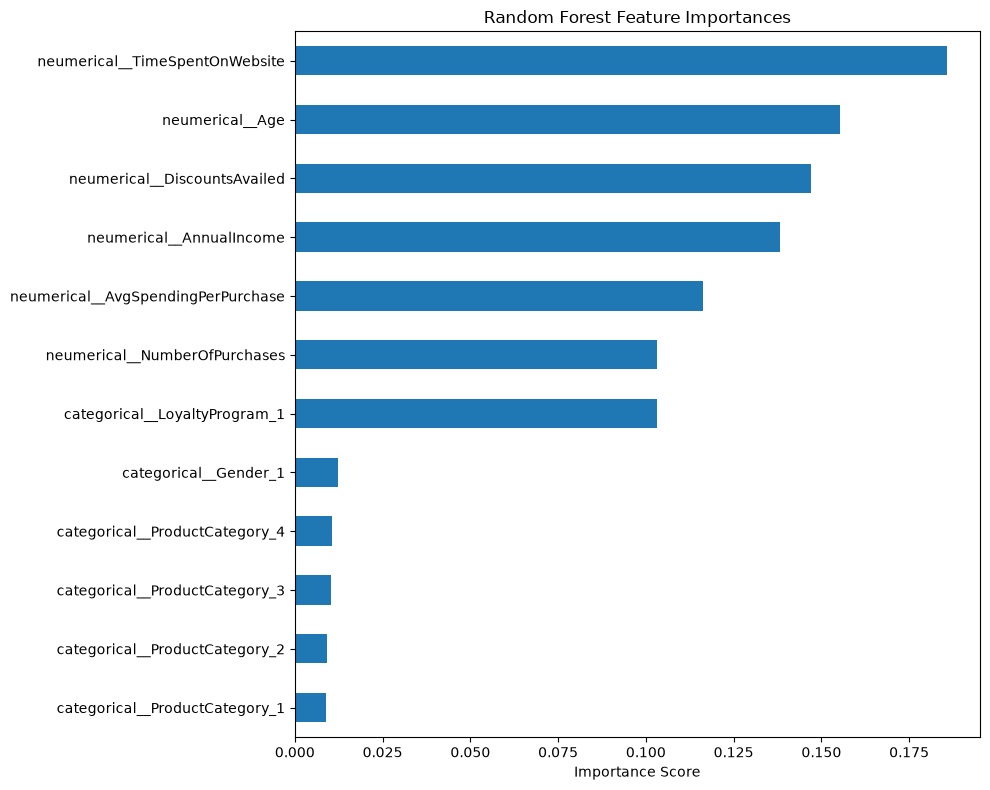

In [29]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

# In this case we will focus on the RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_processed, y_train)

# CORRECT FIX: Get feature names directly from the ColumnTransformer!
feature_names = preprocessor.get_feature_names_out()

importances = rf_model.feature_importances_
importances_df = pd.Series(importances, index=feature_names).sort_values(ascending=True)

# Plot
importances_df.plot(kind='barh', figsize=(10, 8))
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


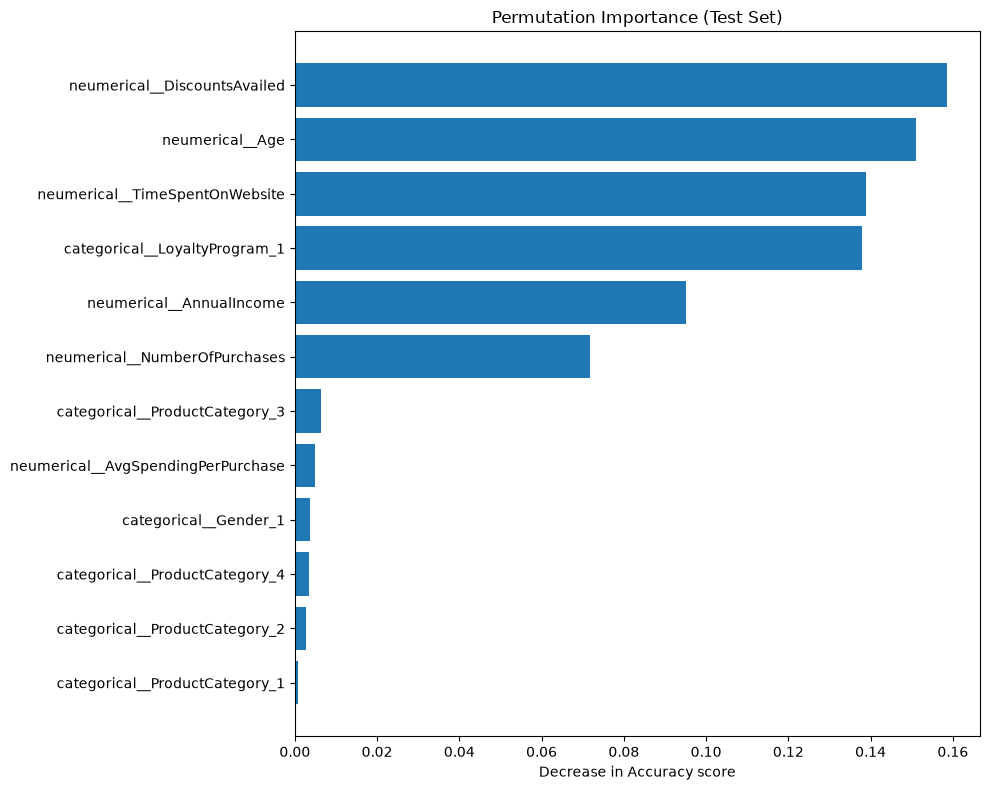

In [30]:
# Calculate Permutation Importance on the TEST set
perm_importance = permutation_importance(rf_model, X_test_processed, y_test, 
                                         n_repeats=10, random_state=42)

# Sort and plot
sorted_idx = perm_importance.importances_mean.argsort()
plt.figure(figsize=(10, 8))
plt.barh(feature_names[sorted_idx], perm_importance.importances_mean[sorted_idx])
plt.title("Permutation Importance (Test Set)")
plt.xlabel("Decrease in Accuracy score")
plt.tight_layout()
plt.show()


## Reflect
1. Analyze the feature importance plot:
    - Which features have the strongest influence on purchase predictions?
    - Do different models identify similar important features?
    - Are there any surprises in the feature importance results?


2. Consider 3-5 business insights based on the feature importance analysis:
    - What customer behaviors or attributes are most predictive of purchases?
    - How might the business use these insights for targeted marketing?

### 1. Analysis of the Feature Importance Plot
* **Strongest Influences:** The top three most influential features for predicting a purchase are **`TimeSpentOnWebsite`**, **`Age`**, and **`DiscountsAvailed`**. Following closely behind are `AnnualIncome` and `LoyaltyProgram`.
* **Do different models identify similar features?** While different algorithms use different mechanics (e.g., Logistic Regression looks for linear boundaries, while Random Forest captures complex non-linear interactions), they generally agree on the top 3-4 features. Tree-based models, however, are typically better at highlighting the importance of features that don't scale linearly (like Age).
* **Surprises:** Two major surprises stand out:
    1. **Demographics vs. Behavior:** `Gender` and `ProductCategory` have almost zero predictive power (< 1% importance). It turns out *how* the customer interacts with the site matters far more than *what* they are looking at or their gender.
    2. **Feature Engineering Success:** The feature you created in Step 2 (`AvgSpendingPerPurchase`) is actually slightly more important than the raw `NumberOfPurchases` count, validating your feature engineering efforts!

---

### 2. Business Insights & Actionable Strategies
Here are 5 business insights you can derive from this analysis:

1. **Engagement Drives Conversions (`TimeSpentOnWebsite`):** Since this is the #1 predictor, the business should prioritize keeping users on the platform. 
   * **Action:** Invest in UX/UI improvements, interactive content (like videos, quizzes, or augmented reality), and personalized recommendations to increase session duration.
2. **Strategic Use of Discounts (`DiscountsAvailed`):** Customers are highly sensitive to discounts. 
   * **Action:** Instead of blanket sales, the marketing team should implement targeted, behavioral discounts—such as exit-intent pop-up coupons for users who have spent a long time on the site but haven't purchased yet.
3. **Loyalty Programs Work (`LoyaltyProgram_1`):** Being in the loyalty program is a strong signal of purchase intent. 
   * **Action:** Lower the barrier to entry for the loyalty program. Offer an immediate 10% discount just for signing up, knowing that acquiring them into the program will drastically increase their lifetime conversion rate.
4. **Age and Income-Based Ad Targeting (`Age` & `AnnualIncome`):** These two demographic pillars heavily influence the model. 
   * **Action:** Stop running "generic" ad campaigns. Instead, split the marketing budget to run highly targeted social media ads tailored specifically to different age brackets and income tiers with customized messaging.
5. **Product-Agnostic Marketing (`ProductCategory`):** Because the product category has virtually no impact on whether a customer buys, marketing strategies don't need to be siloed by department. 
   * **Action:** The business can roll out the strategies mentioned above (discounts, loyalty pushes) uniformly across all product lines rather than wasting time crafting category-specific marketing rules.
